In [49]:
import warnings

warnings.filterwarnings("ignore")

from itertools import groupby

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import spearmanr
from scipy.stats import shapiro

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import textwrap

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

### 1. Получить файл варианта с данными

In [50]:
DATA_PATH = "Вар_42_Б24-215_Гаганидзе_Лаба2_студент.xlsx"
DATA_PATH = "Вар_51_Б24-215_Чугреев_Лаба2_студент.xlsx"
DATA_PATH = "Вар_46_Б24-215_Кузьмина_Лаба2_студент.xlsx"
df_raw = pd.read_excel(DATA_PATH)
print(f"Размер: {df_raw.shape}")
# print(f"Колонки:\n {"\n".join(list(df_raw.columns))}")
display(df_raw)

Размер: (2500, 26)


,ID,"Среднегодовой доход, тыс. $","Объем потребленного алкоголя в год, л.",Количество членов семьи,Количество лет образования,"Доля от дохода семьи которая тратится на продовольствие, %",Коэффициент Джини сообщества,"Издержки сообщества на окружающую среду, млн. $","Охват беспроводной связи в сообществе, %","Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек",Волатильность потребительских цен в сообществе,Сфера занятости,Оценка благополучия,Оценка социальной поддержки,Ожидаемая продолжительность здоровой жизни,Свобода граждан самостоятельно принимать жизненно важные решения,Индекс Щедрости,Индекс отношения к коррупции,Оценка риска безработицы,Индекс кредитного оптимизма,Индекс страха социальных конфликтов,Индекс семьи,Индекс продовольственной безопасности,Чувство технологического прогресса,Чувство неравенства доходов в обществе,Ощущаемое счастье
0,1,393.573,8.59,5,10,35.9,0.436155,114.09,0.618,16.47,2.49,Корпоративный сектор,50.0,60.0,42.0,58.0,38.0,45.0,49.0,49.0,42.0,48.0,30.0,60.0,18.0,Blooming
1,2,95.127,0.00,5,10,53.6,0.541126,113.72,0.950,17.46,1.12,Государственная служба,34.0,56.0,89.0,62.0,24.0,43.0,50.0,34.0,58.0,32.0,21.0,43.0,30.0,Blooming
2,3,406.074,10.08,6,11,37.1,0.436155,114.09,0.618,16.47,2.49,Корпоративный сектор,47.0,61.0,58.0,72.0,33.0,38.0,47.0,64.0,61.0,54.0,48.0,51.0,14.0,Prospering
3,4,180.452,0.00,5,15,35.3,0.560834,130.67,0.853,7.37,1.15,Государственная служба,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Неизвестно
4,5,138.910,0.00,7,13,36.4,0.372639,234.65,0.741,10.52,4.27,Неформальная занятость,58.0,63.0,73.0,89.0,42.0,44.0,14.0,51.0,67.0,46.0,19.0,49.0,12.0,Prospering
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,163.541,0.00,4,12,33.1,0.240399,353.16,0.792,10.91,4.84,Безработный,46.0,33.0,58.0,64.0,45.0,60.0,17.0,51.0,26.0,43.0,15.0,54.0,38.0,Doing well
2496,2497,65.488,8.19,4,9,51.5,0.234011,377.95,0.589,30.97,5.88,Корпоративный сектор,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Неизвестно
2497,2498,213.558,17.09,5,12,47.8,0.265963,354.33,0.730,23.46,4.80,МСП,51.0,30.0,44.0,68.0,40.0,59.0,37.0,48.0,60.0,34.0,43.0,55.0,28.0,Coping
2498,2499,59.108,3.91,4,4,55.2,0.234011,377.95,0.589,30.97,5.88,МСП,56.0,34.0,54.0,58.0,37.0,51.0,53.0,51.0,70.0,13.0,33.0,57.0,43.0,Depressed


In [51]:
df_work = df_raw.drop(columns=["ID"])

grouped_data = [
    (is_numeric, df_work[list(g)])
    for is_numeric, g in groupby(
        df_work.columns, key=lambda c: df_work[c].dtype != "str"
    )
]

for i, (is_numeric, df_group) in enumerate(grouped_data, 1):
    group_type = "Численные" if is_numeric else "Строковые"
    print(f"--- Группа {i} ({group_type}) ---")
    print(*df_group.columns, sep="\n", end="\n\n")

--- Группа 1 (Численные) ---
Среднегодовой доход, тыс. $
Объем потребленного алкоголя в год, л.
Количество членов семьи
Количество лет образования
Доля от дохода семьи которая тратится на продовольствие, %
Коэффициент Джини сообщества
Издержки сообщества на окружающую среду, млн. $
Охват беспроводной связи в сообществе, %
Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек
Волатильность потребительских цен в сообществе

--- Группа 2 (Строковые) ---
Сфера занятости

--- Группа 3 (Численные) ---
Оценка благополучия
Оценка социальной поддержки
Ожидаемая продолжительность здоровой жизни
Свобода граждан самостоятельно принимать жизненно важные решения
Индекс Щедрости
Индекс отношения к коррупции
Оценка риска безработицы
Индекс кредитного оптимизма
Индекс страха социальных конфликтов
Индекс семьи
Индекс продовольственной безопасности
Чувство технологического прогресса
Чувство неравенства доходов в обществе

--- Группа 4 (Строковые) ---
Ощущаемое счастье



### 2. Открыть набор данных и выделить группы признаков: причины, состояния, целевая переменная

In [52]:
# Полный ординальный порядок меток (от худшего к лучшему).
# 'Strugglng' — опечатка в исходных данных, оставляем как есть.
CANTRIL_ORDER = [
    "Hopeless",
    "Depressed",
    "Suffering",
    "Strugglng",
    "Coping",
    "Just ok",
    "Doing well",
    "Blooming",
    "Thriving",
    "Prospering",
]

CANTRIL_COL = df_raw.columns[-1] # "Ощущаемое счастье"
MARKER_UNKNOWN = "Неизвестно" # метка «неизвестно» в этой колонке

ALL_CAUSE, STATE_FEATURES = [
    list(g.columns) for is_numeric, g in grouped_data if is_numeric
]


CAT_FEATURES = [
    col for is_numeric, g in grouped_data
    if not is_numeric and CANTRIL_COL not in g.columns
    for col in g.columns
]

VIF_THRESHOLD = 8.0
PVALUE_THRESHOLD = 0.05
RHO_THRESHOLD = 0.2
R2_THRESHOLD = 0.1
DELTA_THRESHOLD = 0.04
BETA_THRESHOLD = 0.1

### 3. Выделить наблюдения с известным и неизвестным значением счастья

In [53]:
is_unknown = (df_raw[CANTRIL_COL].str.strip() == MARKER_UNKNOWN) | \
    (df_raw[CANTRIL_COL].isna())

df_known = df_raw[~is_unknown].copy()
df_unknown = df_raw[is_unknown].copy()

print(f"Известных записей:   {len(df_known)}")
print(f"Неизвестных записей: {len(df_unknown)}")

actual_classes = [c for c in CANTRIL_ORDER if c in df_known[CANTRIL_COL].unique()]

df_known["rank"] = pd.Categorical(
    df_known[CANTRIL_COL], categories=actual_classes, ordered=True
).codes

print("Кодировка классов:")
for rank, cls in enumerate(actual_classes):
    print(f"  {rank:>2}: {cls}")

Известных записей:   1900
Неизвестных записей: 600
Кодировка классов:
   0: Hopeless
   1: Depressed
   2: Suffering
   3: Strugglng
   4: Coping
   5: Just ok
   6: Doing well
   7: Blooming
   8: Thriving
   9: Prospering


### 4. Провести первичный анализ данных (описательные статистики, визуализация, проверка пропусков)


Пропусков в неизвестных данных:
Оценка благополучия                                                 600
Оценка социальной поддержки                                         600
Ожидаемая продолжительность здоровой жизни                          600
Свобода граждан самостоятельно принимать жизненно важные решения    600
Индекс Щедрости                                                     600
Индекс отношения к коррупции                                        600
Оценка риска безработицы                                            600
Индекс кредитного оптимизма                                         600
Индекс страха социальных конфликтов                                 600
Индекс семьи                                                        600
Индекс продовольственной безопасности                               600
Чувство технологического прогресса                                  600
Чувство неравенства доходов в обществе                              600
dtype: int64




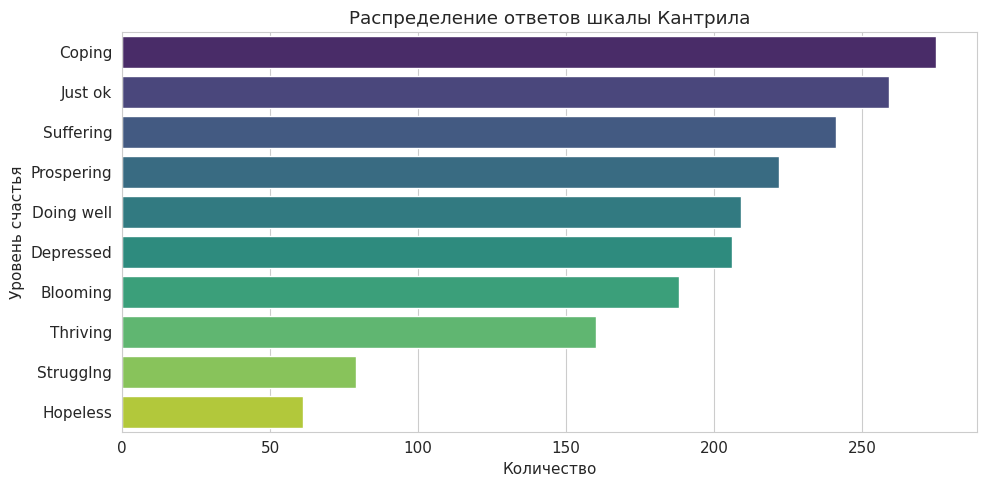

In [54]:
# 1. Проверка пропусков
print("\nПропусков в неизвестных данных:")
missing_info = df_raw.isna().sum()
missing_info = missing_info[missing_info > 0]
if missing_info.empty:
    print("Пропусков нет!\n")
else:
    print(missing_info)
    print("\n")

# 2. Описательные статистики числовых признаков
#print("Описательные числовые статистики:")
#display(df_raw.describe().round(2).T)

# 3. Визуализация распределения целевой переменной
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_known,
    y=CANTRIL_COL,
    order=df_known[CANTRIL_COL].value_counts().index,
    palette="viridis",
)
plt.title("Распределение ответов шкалы Кантрила")
plt.xlabel("Количество")
plt.ylabel("Уровень счастья")
plt.tight_layout()
plt.show()

### 5. Исследовать влияние признаков причины на признаки состояния (корреляционный анализ, линейные регрессии)

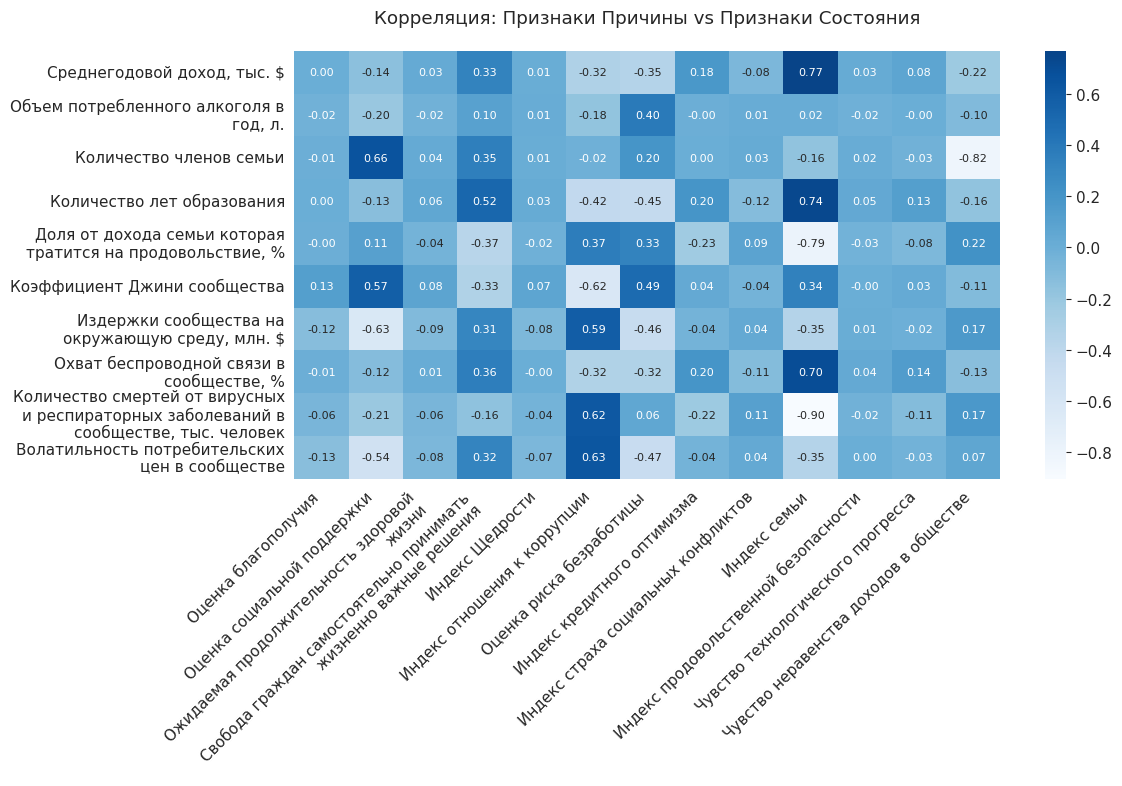

In [55]:
plt.figure(figsize=(12, 8))

cause_state_corr = (
    df_known[ALL_CAUSE + STATE_FEATURES]
    .corr(method="spearman")
    .loc[ALL_CAUSE, STATE_FEATURES]
)

wrapped_y_labels = [textwrap.fill(label, 30) for label in cause_state_corr.index]
wrapped_x_labels = [textwrap.fill(label, 40) for label in cause_state_corr.columns]

sns.heatmap(
    cause_state_corr,
    cmap="Blues",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    yticklabels=wrapped_y_labels,
    xticklabels=wrapped_x_labels,
)
plt.title("Корреляция: Признаки Причины vs Признаки Состояния", pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [56]:
# 1. ЕДИНЫЙ СПЛИТ ДАННЫХ ДЛЯ ВСЕЙ ЛАБОРАТОРНОЙ 
df_train, df_test = train_test_split(
    df_known,
    test_size=0.2,
    random_state=4,
    stratify=df_known["rank"]
)

# 2. Функция VIF только для тренировочных данных
def compute_vif_train(X_df):
    X_const = sm.add_constant(X_df.dropna())
    vif_vals = [variance_inflation_factor(X_const.values, i) for i in range(1, X_const.shape[1])]
    return pd.DataFrame({"Признак": X_df.columns, "VIF": vif_vals}).sort_values("VIF", ascending=False)

# Считаем VIF ТОЛЬКО по Причинам на train
current_cols = ALL_CAUSE
while True:
    vif_res = compute_vif_train(df_train[current_cols])
    worst = vif_res.iloc[0]
    if worst["VIF"] <= VIF_THRESHOLD:
        break
    current_cols.remove(worst["Признак"])

print("Итоговые колонки после VIF (Причины):", *current_cols, sep="\n", end="\n\n")

Итоговые колонки после VIF (Причины):
Среднегодовой доход, тыс. $
Объем потребленного алкоголя в год, л.
Количество членов семьи
Количество лет образования
Доля от дохода семьи которая тратится на продовольствие, %
Коэффициент Джини сообщества
Охват беспроводной связи в сообществе, %
Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек



In [57]:
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.api as sms

# Словарь для сохранения моделей
ols_state_models_full = {} 

for state_col in STATE_FEATURES:
    # Берем строго тренировочный датасет df_train
    valid_data = df_train.dropna(subset=[state_col] + current_cols)
    y_target = valid_data[state_col]
    X_features = sm.add_constant(valid_data[current_cols])

    # Шаг А: Строим базовую OLS для проверки предпосылок
    base_model = sm.OLS(y_target, X_features).fit()
    
    # 1. Проверяем остатки на нормальность (Тест Шапиро-Уилка)
    shapiro_p = stats.shapiro(base_model.resid)[1]
    
    # 2. Проверяем остатки на гетероскедастичность (Тест Бреуша-Пагана)
    bp_test = sms.het_breuschpagan(base_model.resid, X_features)
    bp_pvalue = bp_test[1]  # LM-Test p-value
    
    print("=" * 90)
    print(f"Признак состояния: '{state_col}'")
    print(f"  [Тест Шапиро-Уилка] p-value нормальности остатков: {shapiro_p:.5f}")
    print(f"  [Тест Бреуша-Пагана] p-value гомоскедастичности:  {bp_pvalue:.5f}")

    # Шаг Б: Независимый анализ предпосылок и выбор модели
    cov_type_label = "Unadjusted"
    is_robust = False
    
    # Флаги нарушений
    normality_violated = shapiro_p < PVALUE_THRESHOLD
    hetero_detected = bp_pvalue < 0.05

    if normality_violated:
        if hetero_detected:
            print("  → КРИТИЧЕСКИЙ СЛУЧАЙ: Нарушена нормальность И обнаружена гетероскедастичность!")
            print("    Применяем RLM (Huber) с устойчивой к гетероскедастичности матрицей ковариации H3...")
            # Опция cov='H3' внутри RLM аналогична HC3 в OLS и защищает от гетероскедастичности
            model = sm.RLM(y_target, X_features, M=sm.robust.norms.HuberT()).fit(cov='H3')
            cov_type_label = "Huber + H3 (Hetero)"
        else:
            print("  → Нарушена нормальность остатков. Применяем стандартный RLM (Huber)...")
            model = sm.RLM(y_target, X_features, M=sm.robust.norms.HuberT()).fit()
            cov_type_label = "Huber"
        is_robust = True
                    
    elif hetero_detected:
        print("  → Остатки нормальны, но ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ.")
        print("    Применяем OLS с робастной корректировкой ковариационной матрицы типа HC3...")
        model = sm.OLS(y_target, X_features).fit(cov_type='HC3')
        cov_type_label = "HC3"
        
    else:
        print("  → Предпосылки Гаусса-Маркова соблюдены. Оставляем классический OLS.")
        model = base_model
        
    # Шаг В: Универсальный расчёт Псевдо-R² и стандартизированных Beta
    # Считаем псевдо-R² как квадрат корреляции Пирсона между фактом и прогнозом
    preds = model.predict(X_features)
    r2_value = stats.pearsonr(y_target, preds)[0] ** 2
    
    # Стандартные отклонения для расчета Beta-коэффициентов
    std_y = y_target.std()
    std_X = X_features.std()

    print(f"\nЗначимые факторы для '{state_col}' (R² = {r2_value:.3f}, Huber Штраф: {is_robust}, Cov: {cov_type_label}):")
    
    # Извлекаем t/z-статистики
    t_stats = model.tvalues.drop("const").abs()
    
    for cause_name, t_val in t_stats.items():
        coef = model.params[cause_name]
        
        # Для RLM p-value считаем вручную из z-метрик, для OLS (включая робастный HC3) берем готовые pvalues
        if is_robust:
            p_val = 2 * (1 - stats.norm.cdf(abs(t_val)))
        else:
            p_val = model.pvalues[cause_name]

        # Вычисляем стандартизированный Beta-коэффициент
        beta_coef = coef * (std_X[cause_name] / std_y)

        # Выводим только сильные и статистически значимые связи
        if p_val < PVALUE_THRESHOLD and abs(beta_coef) >= BETA_THRESHOLD:
            print(f"\t• {cause_name}")
            print(f"\t  Направление: {'прямое' if coef > 0 else 'обратное'} (p={p_val:.4f}, Beta={beta_coef:+.3f})")

    # Шаг Г: Сохранение всей информации в виде полей словаря
    ols_state_models_full[state_col] = {
        "model": model, 
        "rsquared": r2_value,
        "is_robust": is_robust,
        "cov_type": cov_type_label
    }

print("\n" + "="*90 + "\nВсе модели успешно обучены и сохранены в словарь ols_state_models_full.")

Признак состояния: 'Оценка благополучия'
  [Тест Шапиро-Уилка] p-value нормальности остатков: 0.35579
  [Тест Бреуша-Пагана] p-value гомоскедастичности:  0.73991
  → Предпосылки Гаусса-Маркова соблюдены. Оставляем классический OLS.

Значимые факторы для 'Оценка благополучия' (R² = 0.025, Huber Штраф: False, Cov: Unadjusted):
	• Коэффициент Джини сообщества
	  Направление: прямое (p=0.0001, Beta=+0.141)
Признак состояния: 'Оценка социальной поддержки'
  [Тест Шапиро-Уилка] p-value нормальности остатков: 0.66016
  [Тест Бреуша-Пагана] p-value гомоскедастичности:  0.39152
  → Предпосылки Гаусса-Маркова соблюдены. Оставляем классический OLS.

Значимые факторы для 'Оценка социальной поддержки' (R² = 0.854, Huber Штраф: False, Cov: Unadjusted):
	• Объем потребленного алкоголя в год, л.
	  Направление: обратное (p=0.0000, Beta=-0.366)
	• Количество членов семьи
	  Направление: прямое (p=0.0000, Beta=+0.660)
	• Коэффициент Джини сообщества
	  Направление: прямое (p=0.0000, Beta=+0.414)
	• Охва

In [58]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

print("=== АВТОМАТИЧЕСКИЙ АНАЛИЗ СКРЫТЫХ КАТЕГОРИАЛЬНЫХ И ЧИСЛОВЫХ СТРАТ ===")

DELTA_THRESHOLD = 0.1  # Порог существенного отклонения (4%)

# Перебираем все обученные модели из сохраненного словаря
for state_col, model_info in ols_state_models_full.items():
    
    # Запускаем анализ СТРОГО там, где была нарушена нормальность (исходные выбросы исказили МНК)
    if model_info["is_robust"]:
        
        # Выделяем валидные данные для текущего состояния
        valid_data = df_train.dropna(subset=[state_col] + current_cols)
        
        # Строим базовый МНК, чтобы вытащить исходные (неоштрафованные) остатки
        base_ols = sm.OLS(valid_data[state_col], sm.add_constant(valid_data[current_cols])).fit()
        
        # Изолируем крупные 2-сигма аномалии
        residuals_series = pd.Series(base_ols.resid, index=valid_data.index)
        threshold = 2 * residuals_series.std()
        anomalies_mask = abs(residuals_series) > threshold
        anomalies = valid_data[anomalies_mask]
        
        print(f"\n" + "="*90)
        print(f"ПРИЗНАК СОСТОЯНИЯ: '{state_col}' (Выявлено крупных аномалий: {len(anomalies)})")
        print("="*90)
        
        # --- БЛОК 1: АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ ---
        print("  [Категориальные страты в аномалиях]:")
        cat_output_found = False
        for cat_col in CAT_FEATURES:
            if cat_col in valid_data.columns:
                train_dist = valid_data[cat_col].value_counts(normalize=True)
                anom_dist = anomalies[cat_col].value_counts(normalize=True) if not anomalies.empty else pd.Series()
                
                # Безопасное вычитание долей аномалий из генеральной совокупности train
                diff_cat = anom_dist.sub(train_dist, fill_value=0)
                
                for category, delta in diff_cat.items():
                    if abs(delta) > DELTA_THRESHOLD:
                        direction = "ЧАЩЕ" if delta > 0 else "РЕЖЕ"
                        if delta > 0:
                            print(f"    * Страта '{category}' ({cat_col}) встречается в аномалиях {direction} (Δ = {delta:+.3f})")
                        cat_output_found = True
        if not cat_output_found:
            print("    → Значимых отклонений по категориальным стратам не обнаружено.")
            
        print("-" * 90)
        
# --- БЛОК 2: АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ ---
        print("  [Числовые страты (терцили) в аномалиях]:")
        for col in current_cols:
            if col in CAT_FEATURES:
                continue
                
            try:
                strata = pd.qcut(valid_data[col], q=3, labels=['Низкий', 'Средний', 'Высокий'], duplicates='drop')
            except Exception:
                continue
            
            train_strata_dist = strata.value_counts(normalize=True)
            anom_strata_dist = strata[anomalies_mask].value_counts(normalize=True) if not anomalies.empty else pd.Series()
            
            diff_num = anom_strata_dist.sub(train_strata_dist, fill_value=0)
            
            has_num_output = False
            for strata_name, delta in diff_num.items():
                # Объединяем условия: проверяем и порог, и направление (delta > DELTA_THRESHOLD)
                if delta > DELTA_THRESHOLD: 
                    if not has_num_output:
                        print(f"    * Фактор: '{col}'")
                        has_num_output = True
                    print(f"      → Страта '{strata_name} уровень' встречается в аномалиях ЧАЩЕ (Δ = {delta:+.3f})")

print("\n" + "="*90 + "\nПолный стратификационный анализ аномалий завершен.")

=== АВТОМАТИЧЕСКИЙ АНАЛИЗ СКРЫТЫХ КАТЕГОРИАЛЬНЫХ И ЧИСЛОВЫХ СТРАТ ===

ПРИЗНАК СОСТОЯНИЯ: 'Свобода граждан самостоятельно принимать жизненно важные решения' (Выявлено крупных аномалий: 78)
  [Категориальные страты в аномалиях]:
    → Значимых отклонений по категориальным стратам не обнаружено.
------------------------------------------------------------------------------------------
  [Числовые страты (терцили) в аномалиях]:
    * Фактор: 'Среднегодовой доход, тыс. $'
      → Страта 'Низкий уровень' встречается в аномалиях ЧАЩЕ (Δ = +0.115)
    * Фактор: 'Количество членов семьи'
      → Страта 'Средний уровень' встречается в аномалиях ЧАЩЕ (Δ = +0.111)
    * Фактор: 'Количество лет образования'
      → Страта 'Низкий уровень' встречается в аномалиях ЧАЩЕ (Δ = +0.163)
    * Фактор: 'Коэффициент Джини сообщества'
      → Страта 'Высокий уровень' встречается в аномалиях ЧАЩЕ (Δ = +0.134)

ПРИЗНАК СОСТОЯНИЯ: 'Индекс отношения к коррупции' (Выявлено крупных аномалий: 73)
  [Категориальные 

### 1. Индекс отношения к коррупции (Выявлено аномалий: 68)
Здесь перекосы относительно небольшие ($\Delta \approx 5-7\%$), но они системны. Линейная модель хуже всего предсказывает отношение к коррупции у граждан с:
1. Высоким доходом. (Δ = +0.049)
2. Низким уровнем потребления алкоголя. (Δ = +0.049)
3. Семьям среднего размера. (Δ = +0.072)

Кластер таких людей описывает *Upper class*.

### 2. Индекс семьи (Выявлено аномалий: 60)
Здесь МНК столкнулся с серьезной проблемой ($\Delta \approx 10-20\%$). Обратите внимание на профиль людей, которые чаще всего улетают в выбросы ($\Delta > 0$):
1. Высокий уровень дохода ($\Delta = +0.117$)
2. Высокий уровень количества членов семьи ($\Delta = +0.084$)
3. Средний уровень образования ($\Delta = +0.165$)
4. Низкий уровень трат на еду ($\Delta = +0.149$)
5. Средний охват беспроводной связи ($\Delta = +0.192$)

Можно сказать, что люди из этих страт приверженцы *Upper-Middle Class*.

### 3. Чувство технологического прогресса (Выявлено аномалий: 60)
Здесь произошел самый мощный методологический провал МНК. Дельты запредельные (($\Delta \approx 30-40\%$)). Посмотрите на этот профиль аномалий:
1. Низкий уровень дохода ($\Delta = +0.267$)
2. Высокий уровень потребления алкоголя ($\Delta = +0.417$ — колоссальный перекос!)
3. Низкий уровень образования ($\Delta = +0.126$)
4. Высокий уровень трат на продовольствие ($\Delta = +0.285$)
5. Низкий коэффициент Джини ($\Delta = +0.332$)
6. Высокий уровень смертности от респираторных заболеваний ($\Delta = +0.357$)

Видно, что описать кластер людей можно как *Low class*.

### Выводы по этапу стратификационного анализа остатков

Проведенный анализ выявил, что нарушения нормальности остатков (зафиксированные тестом Шапиро-Уилка на этапе классического МНК) носят не случайный (стохастический), а выраженный **социально-экономический характер**. Квантование непрерывных признаков на терцили позволило локализовать группы, на которых линейная модель теряет предсказательную силу:

1. **"Индекс отношения к коррупции":** модель нестабильна на подгруппах с высокими доходами и низким потреблением алкоголя.
2. **"Индекс семьи":** зафиксирован методологический излом на представителях условного "верхнего и верхнего-среднего класса" (крупные обеспеченные семьи с минимальной долей расходов на питание).
3. **"Чувство технологического прогресса":** обнаружена критическая гетероскедастичность. Ядром аномалий МНК стали наиболее уязвимые и депрессивные страты (низкий доход, низкое образование, экстремально высокое потребление алкоголя ($\Delta = +41.7\%$) и высокая локальная смертность ($\Delta = +35.7\%$)). 

**Итоговое методологическое решение:**
Поскольку выбросы оказались жестко привязаны к конкретным социальным стратам, их механическое удаление привело бы к потере важнейших сегментов выборки и смещению выводов (*selection bias*). Переход к **робастной линейной регрессии (RLM) с функцией штрафования Хьюбера** является единственно верным решением: алгоритм в процессе итераций автоматически снизил веса (оштрафовал остатки) данных страт, защитив глобальные коэффициенты модели от смещения.

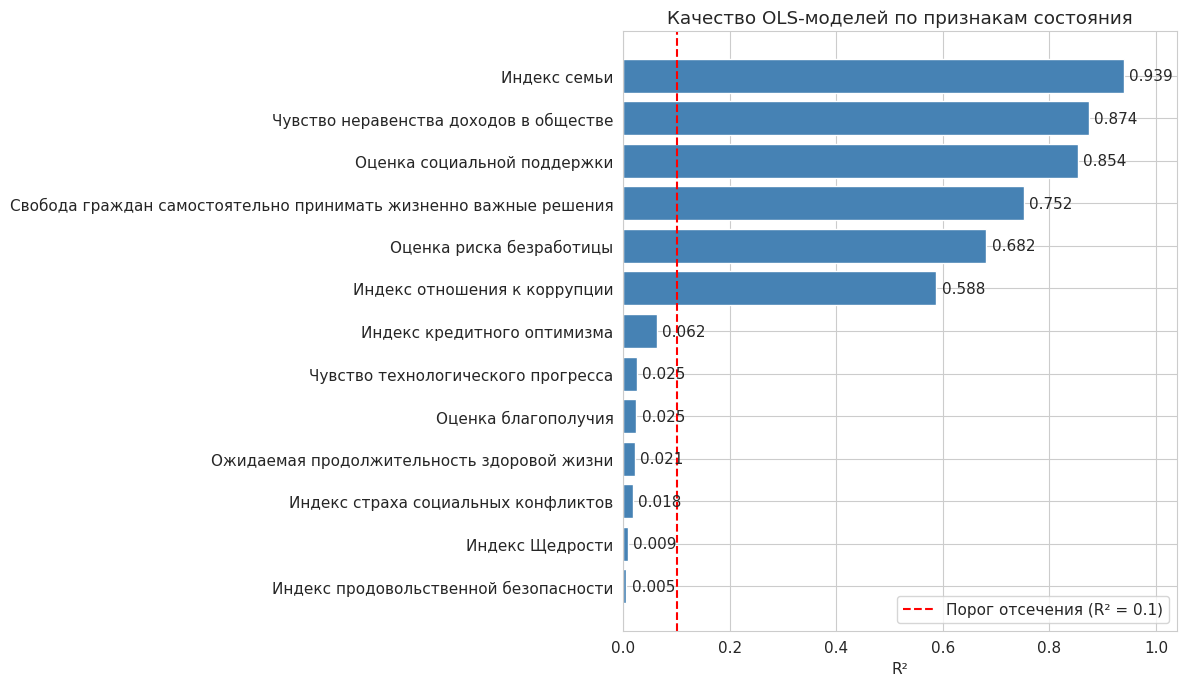

In [59]:
actual_states = [s for s in STATE_FEATURES if s in ols_state_models_full]

rsquared_df = pd.DataFrame(
    {
        "Признак состояния": actual_states,
        "R²": [ols_state_models_full[s]["rsquared"] for s in actual_states],
    }
).sort_values("R²", ascending=True)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    rsquared_df["Признак состояния"], rsquared_df["R²"], color="steelblue"
)
plt.xlabel("R²")
plt.title("Качество OLS-моделей по признакам состояния")

for bar, val in zip(bars, rsquared_df["R²"]):
    plt.text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
    )
plt.axvline(x=R2_THRESHOLD, color='red', linestyle='--', label=f'Порог отсечения (R² = {R2_THRESHOLD})')
plt.legend(loc='lower right')
plt.xlim(0, max(rsquared_df["R²"]) + 0.1)
plt.tight_layout()
plt.show()

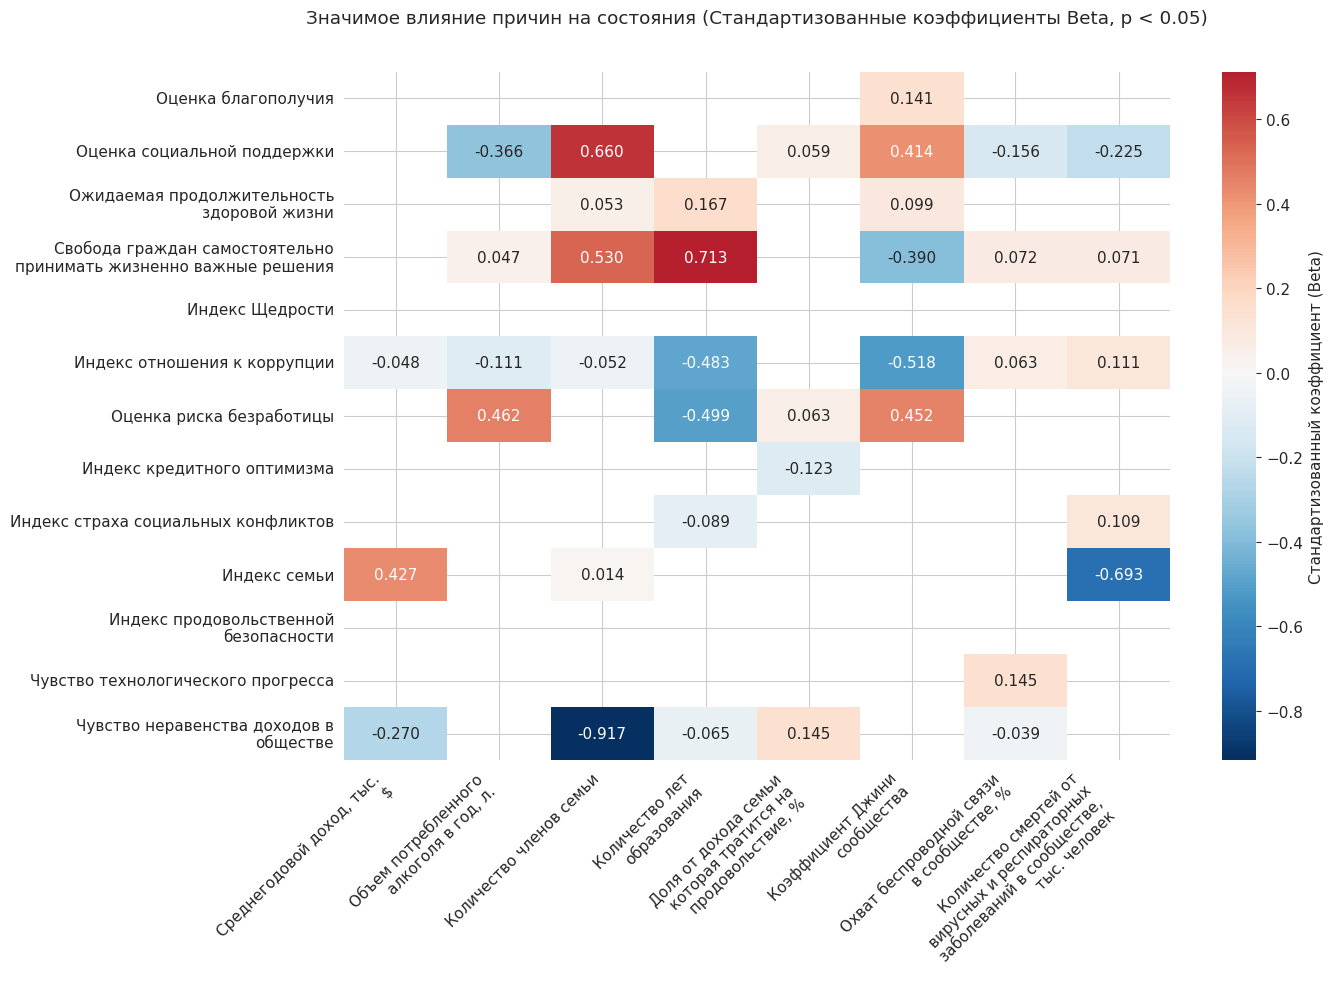

In [60]:
p_val_matrix = pd.DataFrame()
coef_matrix = pd.DataFrame()

# Итерируемся по словарю моделей (внутри лежат словари с моделью и флагом робастности)
for state, model_info in ols_state_models_full.items():
    # Распаковываем объект модели и флаг, применялся ли робастный штраф
    model = model_info["model"]
    is_robust = model_info["is_robust"]
    
    # 1. Безопасный сбор p-value без константы
    t_stats = model.tvalues.drop("const")
    if is_robust:
        # Для RLM (штраф Хьюбера) считаем двустороннее p-value из z-статистик
        p_values = 2 * (1 - stats.norm.cdf(t_stats.abs()))
        p_val_matrix[state] = pd.Series(p_values, index=t_stats.index)
    else:
        # Для обычной OLS берем стандартный атрибут
        p_val_matrix[state] = model.pvalues.drop("const")

    # 2. Считаем СТАНДАРТИЗОВАННЫЕ коэффициенты (Beta) по тренировочным данным
    valid_data = df_train.dropna(subset=[state] + current_cols)
    std_x = valid_data[current_cols].std()
    std_y = valid_data[state].std()

    std_coefs = model.params.drop("const") * (std_x / std_y)
    coef_matrix[state] = std_coefs

# Транспонируем (состояния - строки, причины - столбцы)
p_val_matrix = p_val_matrix.T
coef_matrix = coef_matrix.T

# Создаем матрицу-маску: оставляем коэффициенты ТОЛЬКО там, где p < PVALUE_THRESHOLD
significant_coefs = coef_matrix.mask(p_val_matrix >= PVALUE_THRESHOLD)

# СТРОИМ ОРИГИНАЛЬНЫЙ ГРАФИК (ТИП И СТИЛИСТИКА ПОЛНОСТЬЮ СОХРАНЕНЫ)
plt.figure(figsize=(14, 10))
sns.heatmap(
    significant_coefs,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".3f",
    xticklabels=[textwrap.fill(c, 25) for c in significant_coefs.columns],
    yticklabels=[textwrap.fill(c, 35) for c in significant_coefs.index],
    cbar_kws={"label": "Стандартизованный коэффициент (Beta)"},
)

plt.title(
    "Значимое влияние причин на состояния (Стандартизованные коэффициенты Beta, p < 0.05)\n",
    pad=20,
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6. Проверить влияние категориальных факторов на признаки состояния (например, сфера занятости; ANOVA, тест Манна—Уитни)

In [61]:
for cat_feature in CAT_FEATURES:
    groups = df_known[cat_feature].dropna().unique()
    print(
        f"Влияние категориального фактора '{cat_feature}' на признаки состояния\n"
    )

    for state_col in STATE_FEATURES:
        # Собираем значения признака состояния для каждой отдельной категории
        group_data = [
            df_known[df_known[cat_feature] == g][state_col].dropna()
            for g in groups
        ]

        # Отфильтруем группы, в которых слишком мало наблюдений (например, < 5)
        group_data = [d for d in group_data if len(d) >= 5]

        if len(group_data) == 2:
            # Если ровно 2 группы (например, Мужчины / Женщины) -> Тест Манна-Уитни
            stat, p_val = stats.mannwhitneyu(
                group_data[0], group_data[1], alternative="two-sided"
            )
            test_name = "Манна-Уитни"

        elif len(group_data) > 2:
            # Если 3 и более групп (например, разные сферы занятости) -> Краскела-Уоллиса (непараметрический ANOVA)
            # Используем его вместо классического f_oneway ANOVA, так как он не требует нормальности распределения
            stat, p_val = stats.kruskal(*group_data)
            test_name = "Краскела-Уоллиса (ANOVA)"
        else:
            continue

        if p_val < PVALUE_THRESHOLD:
            print(f"Признак: {state_col}")
            print(f"  Тест: {test_name} | p-value = {p_val} \n")

Влияние категориального фактора 'Сфера занятости' на признаки состояния

Признак: Оценка риска безработицы
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 0.007653109632559149 



### 7. Отобрать значимые и интерпретируемые признаки состояния

In [62]:
# 1. СПЛИТ ДАННЫХ (Уже сделан в шаге 5 в едином месте)
# Сразу выделяем целевые метки для ML-моделей
y_train = df_train["rank"]
y_test = df_test["rank"]

print(f"Размер обучающей выборки (train): {df_train.shape[0]} записей")
print(f"Размер тестовой выборки (test): {df_test.shape[0]} записей\n")

# 2. ОТБОР ПРИЗНАКОВ (Только на Train, чтобы избежать data leakage)

corr_results = []
for col in STATE_FEATURES:
    valid = df_train[[col, "rank"]].dropna()
    if len(valid) < 10:
        continue
    rho, pval = spearmanr(valid[col], valid["rank"])
    corr_results.append(
        {"Признак состояния": col, "Spearman": rho, "p-value": pval}
    )

corr_df = pd.DataFrame(corr_results).sort_values(
    "Spearman", key=abs, ascending=False
)
#print("Все корреляции:")
#print(corr_df.to_string(index=False))

# Берём: 1) статистически значимые + 2) с адекватной силой связи
selected_state = corr_df[
    (corr_df["p-value"] < PVALUE_THRESHOLD)
    & (corr_df["Spearman"].abs() >= RHO_THRESHOLD)
]["Признак состояния"].tolist()

print(f"\nОтобраны признаки состояния (p < {PVALUE_THRESHOLD} и |ρ| >= {RHO_THRESHOLD}): {len(selected_state)} шт.")
for f in selected_state:
    row = corr_df[corr_df["Признак состояния"] == f].iloc[0]
    print(f"  ρ={row['Spearman']:+.3f}  p={row['p-value']:.2e}  {f}")

Размер обучающей выборки (train): 1520 записей
Размер тестовой выборки (test): 380 записей


Отобраны признаки состояния (p < 0.05 и |ρ| >= 0.2): 7 шт.
  ρ=+0.683  p=5.55e-209  Индекс семьи
  ρ=+0.610  p=9.20e-156  Свобода граждан самостоятельно принимать жизненно важные решения
  ρ=-0.585  p=3.53e-140  Индекс отношения к коррупции
  ρ=-0.581  p=3.29e-138  Чувство неравенства доходов в обществе
  ρ=+0.284  p=1.43e-29  Оценка социальной поддержки
  ρ=-0.215  p=2.12e-17  Оценка риска безработицы
  ρ=+0.200  p=3.05e-15  Индекс кредитного оптимизма


In [63]:
from IPython.display import Markdown
display(Markdown(f"### Видим, что каждый из {len(selected_state)} признаков значимый и интерпретируемый (есть логическая связь с целевой переменной)."))

### Видим, что каждый из 7 признаков значимый и интерпретируемый (есть логическая связь с целевой переменной).

Индекс семьи
Свобода граждан самостоятельно принимать жизненно важные решения
Индекс отношения к коррупции
Чувство неравенства доходов в обществе
Оценка социальной поддержки
Оценка риска безработицы
Индекс кредитного оптимизма


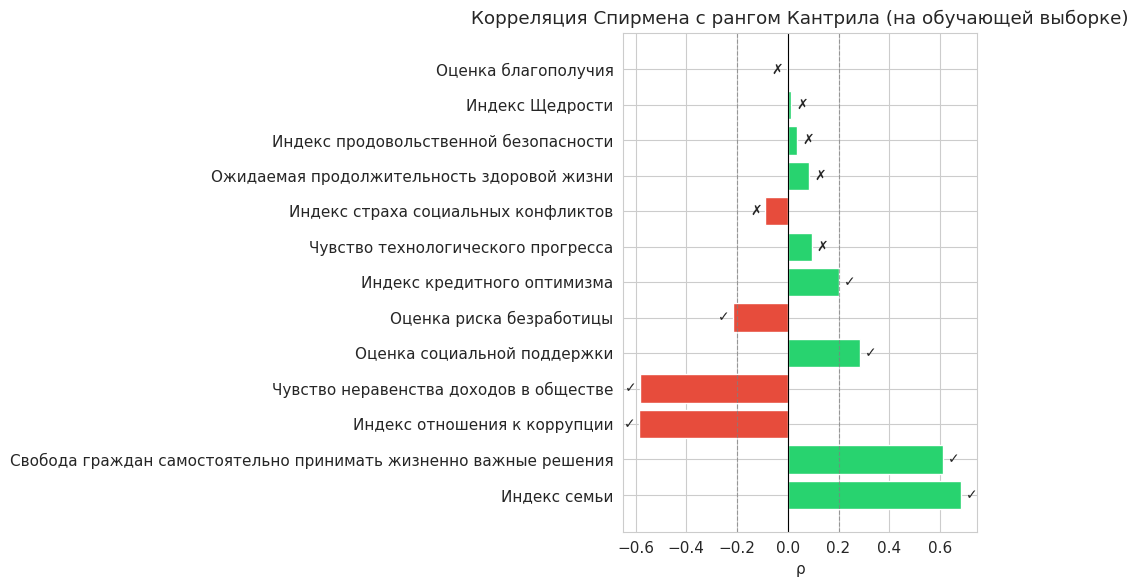

In [64]:
# 3. ВИЗУАЛИЗАЦИЯ
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#28d36f" if r > 0 else "#e74c3c" for r in corr_df["Spearman"]]
ax.barh(corr_df["Признак состояния"], corr_df["Spearman"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

# Рисуем пороги отсечения (пунктиром)
ax.axvline(
    RHO_THRESHOLD, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
)
ax.axvline(
    -RHO_THRESHOLD, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
)

for i, (_, row) in enumerate(corr_df.iterrows()):
    is_selected = (row["p-value"] < PVALUE_THRESHOLD) and (
        abs(row["Spearman"]) >= RHO_THRESHOLD
    )
    marker = "✓" if is_selected else "✗"
    if is_selected:
        print(row["Признак состояния"])
    x = row["Spearman"]
    ax.text(
        x + (0.02 if x >= 0 else -0.06), i, marker, va="center", fontsize=10
    )

ax.set_title("Корреляция Спирмена с рангом Кантрила (на обучающей выборке)")
ax.set_xlabel("ρ")
plt.tight_layout()
plt.show()


### 9. Построить модели прогноза признаков состояния по признакам причины

ПРЕДСКАЗАНИЯ ДЛЯ ОТОБРАННЫХ ПРИЗНАКОВ СОСТОЯНИЯ (RLM / OLS)

 Признак Свобода граждан самостоятельно принимать жизненно важные решения
  Тип модели:       RLM (Штраф Хьюбера)
  Тип ковариации:   Huber + H3 (Hetero)
  Псевдо-R²:        0.752
  Durbin-Watson:    2.082
  Распределение остатков:   НЕНОРМАЛЬНЫ (Выявлено на этапе обучения OLS, применен RLM)


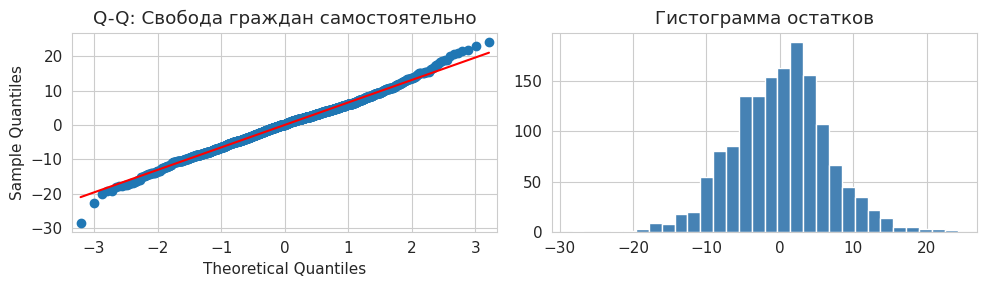


 Признак Индекс отношения к коррупции
  Тип модели:       RLM (Штраф Хьюбера)
  Тип ковариации:   Huber + H3 (Hetero)
  Псевдо-R²:        0.588
  Durbin-Watson:    1.994
  Распределение остатков:   НЕНОРМАЛЬНЫ (Выявлено на этапе обучения OLS, применен RLM)


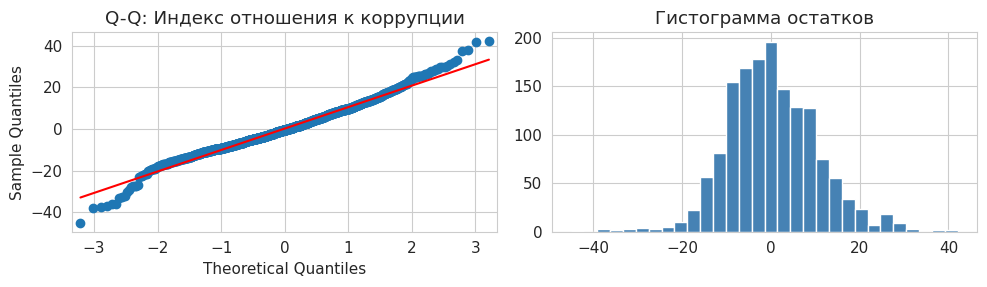


 Признак Чувство неравенства доходов в обществе
  Тип модели:       RLM (Штраф Хьюбера)
  Тип ковариации:   Huber + H3 (Hetero)
  Псевдо-R²:        0.874
  Durbin-Watson:    2.041
  Распределение остатков:   НЕНОРМАЛЬНЫ (Выявлено на этапе обучения OLS, применен RLM)


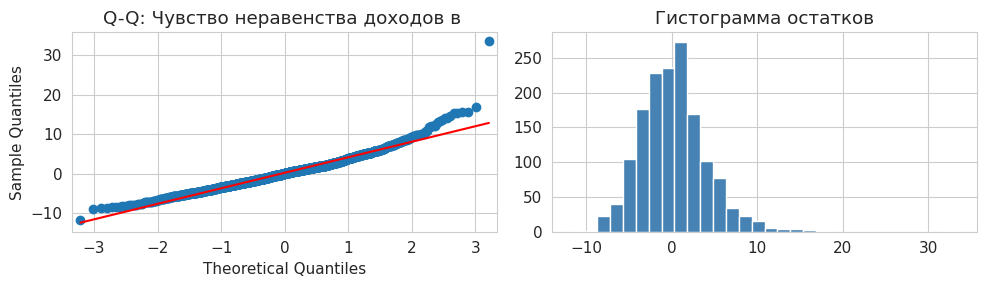


 Признак Оценка риска безработицы
  Тип модели:       RLM (Штраф Хьюбера)
  Тип ковариации:   Huber + H3 (Hetero)
  Псевдо-R²:        0.682
  Durbin-Watson:    1.968
  Распределение остатков:   НЕНОРМАЛЬНЫ (Выявлено на этапе обучения OLS, применен RLM)


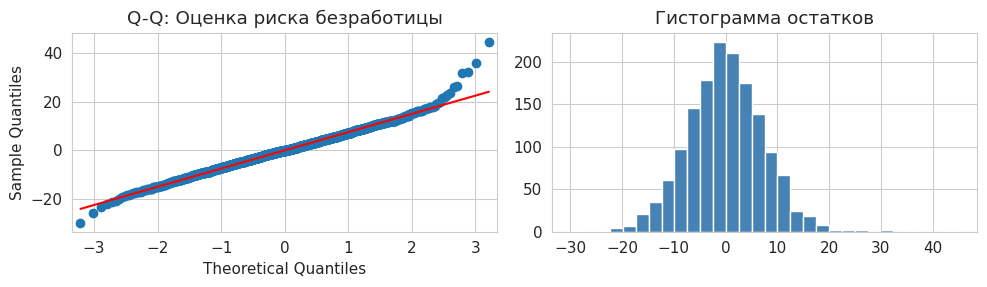


Моделей отобрано и предсказано: 7


In [65]:
ols_models = {}
ols_predictions_train = pd.DataFrame(index=df_train.index)
ols_predictions_test = pd.DataFrame(index=df_test.index)
ols_predictions_unk = pd.DataFrame(index=df_unknown.index)

print("ПРЕДСКАЗАНИЯ ДЛЯ ОТОБРАННЫХ ПРИЗНАКОВ СОСТОЯНИЯ (RLM / OLS)")

# Медианы причин считаем один раз по train
cause_medians = df_train[current_cols].median()

for target_col in selected_state:
    # Забираем уже обученные робастные модели
    model_info = ols_state_models_full[target_col]
    model = model_info["model"]
    is_robust = model_info["is_robust"]
    r2_val = model_info["rsquared"]
    cov_type_label = model_info.get("cov_type", "Unadjusted")

    ols_models[target_col] = {
        "model": model, 
        "features": current_cols,
        "rsquared": r2_val,
        "is_robust": is_robust,
        "cov_type": cov_type_label
    }

    dw = durbin_watson(model.resid)
    # Было: shapiro_stat, shapiro_p = stats.shapiro(model.resid)
    # Стало: ориентируемся на сохраненный флаг робастности
    if is_robust:
        print(f"\n Признак {target_col}")
        normality_verdict = "НЕНОРМАЛЬНЫ (Выявлено на этапе обучения OLS, применен RLM)"
        print(f"  Тип модели:       {'RLM (Штраф Хьюбера)' if is_robust else 'МНК (OLS)'}")
        print(f"  Тип ковариации:   {cov_type_label}")
        print(f"  Псевдо-R²:        {r2_val:.3f}")
        print(f"  Durbin-Watson:    {dw:.3f}")
        print(f"  Распределение остатков:   {normality_verdict}")

        # Q-Q plot и гистограмма
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        sm.qqplot(model.resid, line="s", ax=axes[0])
        axes[0].set_title(f"Q-Q: {target_col[:30]}")
        axes[1].hist(model.resid, bins=30, color="steelblue", edgecolor="white")
        axes[1].set_title("Гистограмма остатков")
        plt.tight_layout()
        plt.show()
    else:
        normality_verdict = f"НОРМАЛЬНЫ (p-value = {shapiro_p:.5f} >= {PVALUE_THRESHOLD})"

    # Формируем предсказания для всех трёх частей
    for src_df, store in [
        (df_train, ols_predictions_train),
        (df_test, ols_predictions_test),
        (df_unknown, ols_predictions_unk),
    ]:
        # Заполняем пропуски в причинах медианами train перед прогнозом
        X_filled = src_df[current_cols].fillna(cause_medians)
        Xp = sm.add_constant(X_filled, has_constant="add")
        store[target_col] = model.predict(Xp)

print(f"\nМоделей отобрано и предсказано: {len(ols_models)}")

### 10. По наблюдениям с известным счастьем построить модель классификации счастья (логистическая / мультиномиальная логистическая регрессия)

Признаков для df_known (все реальные):   ['Индекс семьи', 'Свобода граждан самостоятельно принимать жизненно важные решения', 'Индекс отношения к коррупции', 'Чувство неравенства доходов в обществе', 'Оценка социальной поддержки', 'Оценка риска безработицы', 'Индекс кредитного оптимизма']
Признаков для df_unknown (надежные RLM/OLS): ['Индекс семьи', 'Свобода граждан самостоятельно принимать жизненно важные решения', 'Индекс отношения к коррупции', 'Чувство неравенства доходов в обществе', 'Оценка социальной поддержки', 'Оценка риска безработицы']

Итого признаков для классификатора (после выравнивания): 19
Fitting 5 folds for each of 28 candidates, totalling 140 fits

Лучшие параметры: {'classifier__C': 0.5, 'classifier__class_weight': None, 'classifier__penalty': 'l1'}
CV micro precision (train): 0.781

Micro Precision (test): 0.776  (критерий: > 0.6)
Критерий ВЫПОЛНЕН ✓

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00  

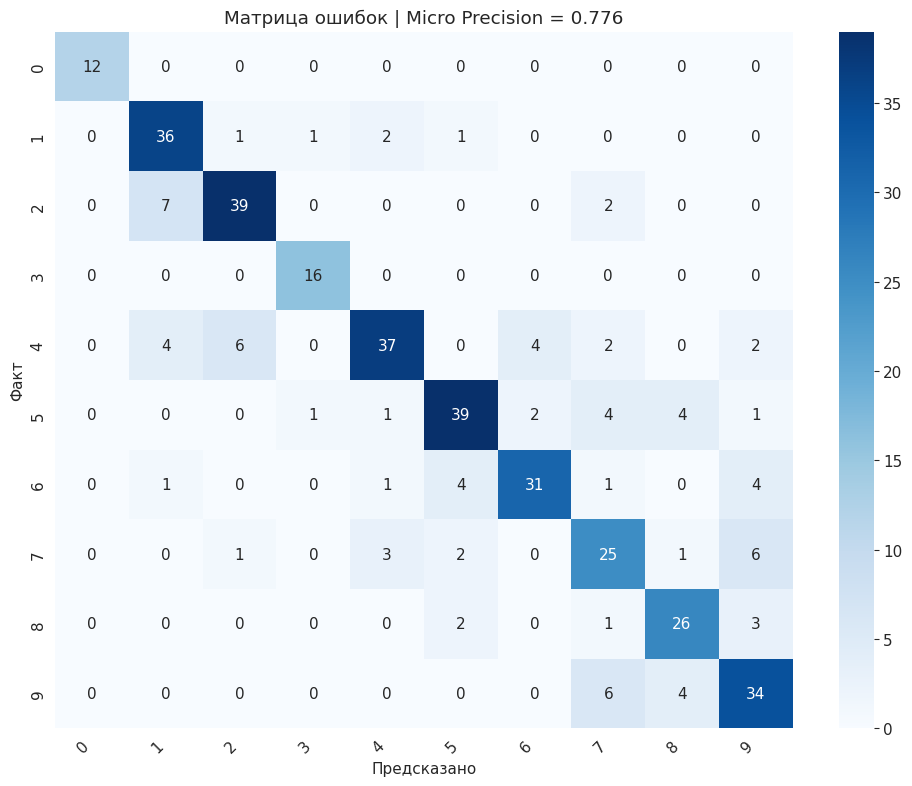

In [66]:
# ─── ФИНАЛЬНЫЕ ПРИЗНАКИ ───────────────────────────────────────────
# ИСПРАВЛЕНИЕ ОШИБКИ И ОТБОР НАДЕЖНЫХ СОСТОЯНИЙ ДЛЯ UNKNOWN
# Теперь обращаемся напрямую к ключу "rsquared", где сохранен Псевдо-R² для RLM
final_states = [
    col
    for col in selected_state
    if col in ols_models and ols_models[col]["rsquared"] >= R2_THRESHOLD
]

print("Признаков для df_known (все реальные):  ", selected_state)
print("Признаков для df_unknown (надежные RLM/OLS):", final_states)

# =====================================================================
# РАСЧЕТ МЕДИАН (СТРОГО НА TRAIN ДЛЯ ИСКЛЮЧЕНИЯ УТЕЧЕК)
# =====================================================================
cause_medians = df_train[current_cols].median()
real_state_medians_train = df_train[selected_state].median()

# =====================================================================
# ГЕНЕРАЦИЯ ПРЕДСКАЗАНИЙ OLS ДЛЯ СКРЫТОЙ ВЫБОРКИ (UNKNOWN)
# =====================================================================
ols_predictions_train = pd.DataFrame(index=df_train.index)
ols_predictions_test = pd.DataFrame(index=df_test.index)
ols_predictions_unk = pd.DataFrame(index=df_unknown.index)

for state_col in final_states:
    model = ols_models[state_col]["model"]
    
    X_tr = sm.add_constant(df_train[current_cols])
    ols_predictions_train[state_col] = model.predict(X_tr)

    X_te = sm.add_constant(df_test[current_cols])
    ols_predictions_test[state_col] = model.predict(X_te)

    X_un = sm.add_constant(df_unknown[current_cols])
    ols_predictions_unk[state_col] = model.predict(X_un)

# Расчет медиан для OLS-прогнозов
state_medians_ols = ols_predictions_train[final_states].median()

# =====================================================================
# УНИВЕРСАЛЬНАЯ ФУНКЦИЯ СБОРКИ МАТРИЦ ПРИЗНАКОВ (build_X)
# =====================================================================
def build_X(source_df, use_ols_predictions=False, ols_preds_df=None, train_cols=None):
    """
    Универсальный конвейер: Причины + Состояния (Реальные ИЛИ Прогнозы) + Категории.
    Выравнивает структуру колонок относительно обучающей выборки.
    """
    # 1. Причины (VIF признаки)
    X_c = source_df[current_cols].fillna(cause_medians).reset_index(drop=True)
    
    # 2. Признаки состояний (Переключение по флагу методологии)
    if use_ols_predictions:
        # Для скрытой выборки (unknown) берем только надежные OLS-предсказания
        X_s = ols_preds_df[final_states].fillna(state_medians_ols).reset_index(drop=True)
    else:
    # Для известных данных (train/test) берем НАСТОЯЩИЕ чистые значения из датасета
        X_s = source_df[selected_state].fillna(real_state_medians_train).reset_index(drop=True)
    
    # 3. Категориальные переменные
    X_cat = pd.get_dummies(source_df[CAT_FEATURES].reset_index(drop=True), drop_first=True)
    
    # Объединяем блоки в итоговую матрицу
    X_res = pd.concat([X_c, X_s, X_cat], axis=1)
    
    # 4. Жесткое выравнивание признаков по тренировочной матрице
    if train_cols is not None:
        for col in set(train_cols) - set(X_res.columns):
            X_res[col] = 0
        X_res = X_res[train_cols]
        
    return X_res

# Сборка финальных датасетов
X_clf_train = build_X(df_train, use_ols_predictions=True, ols_preds_df=ols_predictions_train)
train_columns = X_clf_train.columns.tolist()

X_clf_test  = build_X(df_test, use_ols_predictions=True, ols_preds_df=ols_predictions_test, train_cols=train_columns)
X_clf_unk   = build_X(df_unknown, use_ols_predictions=True, ols_preds_df=ols_predictions_unk, train_cols=train_columns)

print(f"\nИтого признаков для классификатора (после выравнивания): {X_clf_train.shape[1]}")


# ─── КЛАССИФИКАТОР ────────────────────────────────────────────────
y_train_labels = y_train.values
y_test_labels  = y_test.values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="saga",       # поддерживает и l1 и l2
        max_iter=5000,
        random_state=42,
    )),
])

param_grid = {
    "classifier__C":            [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    "classifier__penalty":      ["l1", "l2"],
    "classifier__class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    pipe, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="precision_micro",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_clf_train, y_train_labels)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"CV micro precision (train): {grid_search.best_score_:.3f}")

clf_pipeline   = grid_search.best_estimator_
y_pred_labels  = clf_pipeline.predict(X_clf_test)

micro_prec = precision_score(
    y_test_labels, y_pred_labels,
    average="micro",
    labels=sorted(set(y_test_labels) | set(y_pred_labels)),
)
print(f"\nMicro Precision (test): {micro_prec:.3f}  (критерий: > 0.6)")
print("Критерий", "ВЫПОЛНЕН ✓" if micro_prec > 0.6 else "НЕ выполнен ✗")

actual_test_classes = sorted(list(set(y_test_labels)))
print("\nClassification Report:\n")
print(
    classification_report(
        y_test_labels,
        y_pred_labels,
        labels=actual_test_classes,
        zero_division=0,
    )
)

# Визуализация матрицы ошибок
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=actual_test_classes)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actual_test_classes,
    yticklabels=actual_test_classes,
    ax=ax,
)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Факт")
ax.set_title(f"Матрица ошибок | Micro Precision = {micro_prec:.3f}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 12. Спрогнозировать неизвестные значения счастья

In [67]:
df_unknown_predicted = df_unknown.copy()

# Передаем данные в pipeline (он сам масштабирует)
df_unknown_predicted["Predicted_Happiness"] = clf_pipeline.predict(X_clf_unk)

# Обратно декодируем числа классов в текстовые метки
rank_to_class = {i: cls for i, cls in enumerate(actual_classes)}
df_unknown_predicted["Predicted_Class"] = df_unknown_predicted[
    "Predicted_Happiness"
].map(rank_to_class)

# Предсказываем вероятности
probs = clf_pipeline.predict_proba(X_clf_unk)

# Добавляем вероятности в датафрейм
for i, class_idx in enumerate(clf_pipeline.named_steps["classifier"].classes_):
    class_name = rank_to_class.get(class_idx, f"Class_{class_idx}")
    df_unknown_predicted[f"Prob_{class_name}"] = np.round(probs[:, i], 3)

print("--- Распределение предсказанных групп ---")
print(df_unknown_predicted["Predicted_Class"].value_counts(dropna=False))

print("\n--- Первые 5 строк с прогнозами ---")
prob_cols = [
    col for col in df_unknown_predicted.columns if col.startswith("Prob_")
]
cols_to_show = [CANTRIL_COL, "Predicted_Class"] + prob_cols

display(df_unknown_predicted[cols_to_show].head())

--- Распределение предсказанных групп ---
Predicted_Class
Just ok       96
Coping        83
Depressed     74
Doing well    67
Prospering    64
Suffering     63
Blooming      59
Thriving      54
Strugglng     24
Hopeless      16
Name: count, dtype: int64

--- Первые 5 строк с прогнозами ---


,Ощущаемое счастье,Predicted_Class,Prob_Hopeless,Prob_Depressed,Prob_Suffering,Prob_Strugglng,Prob_Coping,Prob_Just ok,Prob_Doing well,Prob_Blooming,Prob_Thriving,Prob_Prospering
3,Неизвестно,Thriving,0.0,0.000,0.000,0.000,0.000,0.012,0.002,0.024,0.582,0.380
9,Неизвестно,Doing well,0.0,0.000,0.000,0.026,0.027,0.340,0.413,0.011,0.087,0.095
13,Неизвестно,Coping,0.0,0.002,0.021,0.000,0.711,0.138,0.077,0.031,0.000,0.019
15,Неизвестно,Coping,0.0,0.000,0.009,0.000,0.469,0.165,0.175,0.061,0.002,0.119
23,Неизвестно,Strugglng,0.0,0.000,0.000,0.935,0.000,0.007,0.057,0.000,0.000,0.000


In [68]:
# 1. Какие модели в ols_state_models_full и их R²
for col, info in ols_state_models_full.items():
    print(f"{col}: is_robust={info['is_robust']}, R²={info['rsquared']:.3f}")

# 2. Какие модели в ols_models (из Cell 28) и их R²  
for col, info in ols_models.items():
    print(f"{col}: R²={info['model'].rsquared:.3f}")

Оценка благополучия: is_robust=False, R²=0.025
Оценка социальной поддержки: is_robust=False, R²=0.854
Ожидаемая продолжительность здоровой жизни: is_robust=False, R²=0.021
Свобода граждан самостоятельно принимать жизненно важные решения: is_robust=True, R²=0.752
Индекс Щедрости: is_robust=False, R²=0.009
Индекс отношения к коррупции: is_robust=True, R²=0.588
Оценка риска безработицы: is_robust=True, R²=0.682
Индекс кредитного оптимизма: is_robust=False, R²=0.062
Индекс страха социальных конфликтов: is_robust=False, R²=0.018
Индекс семьи: is_robust=False, R²=0.939
Индекс продовольственной безопасности: is_robust=False, R²=0.005
Чувство технологического прогресса: is_robust=False, R²=0.025
Чувство неравенства доходов в обществе: is_robust=True, R²=0.874
Индекс семьи: R²=0.939


AttributeError: 'RLMResults' object has no attribute 'rsquared'